In [1]:
import pandas as pd
import numpy as np
from scipy.stats import zscore
from pathlib import Path
import geopandas as gpd
import json
import os
from scipy.ndimage import gaussian_filter1d

from lib import groundwater_qc

import matplotlib.pyplot as plt

%config InlineBackend.figure_formats = ['svg']

In [2]:
df_baro = pd.read_csv("/Users/dillonragar/Downloads/VBG.csv")

In [3]:
df_pcp = pd.read_parquet(
    "/Users/dillonragar/github/TNC_dangermond/station_data/output/qc/GHCND:USC00045064_19770101_20240430.parquet"
)
df_pcp.index = df_pcp.index.tz_localize("utc")

In [4]:
df_pcp

datatype,PRCP,TMAX,TMIN,TOBS,station
date,,,,,
1977-01-01 00:00:00+00:00,0.0,16.1,3.9,13.9,GHCND:USC00045064
1977-01-02 00:00:00+00:00,1.3,15.0,9.4,12.2,GHCND:USC00045064
1977-01-03 00:00:00+00:00,14.5,15.0,5.6,13.3,GHCND:USC00045064
1977-01-04 00:00:00+00:00,0.0,14.4,0.6,12.8,GHCND:USC00045064
1977-01-05 00:00:00+00:00,7.9,13.3,1.1,7.8,GHCND:USC00045064
...,...,...,...,...,...
2024-04-26 00:00:00+00:00,NaN,NaN,NaN,NaN,GHCND:USC00045064
2024-04-27 00:00:00+00:00,NaN,NaN,NaN,NaN,GHCND:USC00045064
2024-04-28 00:00:00+00:00,NaN,NaN,NaN,NaN,GHCND:USC00045064


In [5]:
# load hydrofabric to get catchment id
gdf = gpd.read_file(
    "/Users/dillonragar/github/tnc_webapp/data/jldp_ngen_nhdhr.gpkg", layer="wells"
)
gdf = gdf.to_crs("EPSG:4326")

In [6]:
gdf

,name,station_id_dendra,divide_id,id,toid,geometry
0,Cistern Water Tank,,cat-118,wb-118,nex-47,POINT (-120.41940 34.49000)
1,Cojo HQ Water Tank,,cat-49,wb-49,tnx-1000000012,POINT (-120.44520 34.45850)
2,Dangermond Alegria,64dbe91cd0708704d6d53d8c,cat-45,wb-45,nex-46,POINT (-120.42443 34.47962)
3,Dangermond Alexander Ramajal,64dbe9ce2148db3f6f481b1a,cat-43,wb-43,nex-44,POINT (-120.41613 34.53257)
4,Dangermond Buckhorn 1,64dbe9c755264579ef3ea324,cat-113,wb-113,nex-14,POINT (-120.38473 34.51295)
...,...,...,...,...,...,...
66,Santa Cruz Island Main Ranch South Well,60ca468be59e3ba96d7911d1,None,None,None,POINT (-119.72164 33.99576)
67,Santa Cruz Island Nursery Weather Station,63686470b055ac33a4843a58,None,None,None,POINT (-119.67692 33.98944)
68,Santa Cruz Island Pelican Pines,63645ca25d4311382ce55686,None,None,None,POINT (-119.68415 34.01605)
69,Santa Cruz Island Prsoner Well Gauge,63686563b055ac80f1843a5b,None,None,None,POINT (-119.68415 34.01605)


In [28]:
# load baro data
df_baro = pd.read_csv("/Users/dillonragar/Downloads/VBG.csv")

df_baro = df_baro[["mslp", "valid", "lat", "lon"]]
df_baro.index = pd.to_datetime(df_baro["valid"], utc=True)
df_baro["press_feet"] = df_baro["mslp"] * 0.0101972  # UNIT: mbar to meters water column
df_baro = df_baro.resample("h").mean(numeric_only=True)
df_baro["press_m"] = df_baro["press_feet"].interpolate(method="time")
# df_baro["press_m"].loc["2009-01-10":"2011-04-01"].plot(figsize=(12, 4))

In [8]:
directory = Path(
    "/Users/dillonragar/github/TNC_dangermond/station_data/output/tnc_datastreams_v3/"
)


depth_files_recursive = [
    file for file in directory.rglob("*Well_Water_Level.parquet") if "" in file.name
]

In [9]:
depth_files_recursive

[PosixPath('/Users/dillonragar/github/TNC_dangermond/station_data/output/tnc_datastreams_v3/Dangermond_Diamond_Corral/DangermondDiamondcorral_Well_Water_Level.parquet'),
 PosixPath('/Users/dillonragar/github/TNC_dangermond/station_data/output/tnc_datastreams_v3/Dangermond_Gaspar_2/DangermondGaspar2_Well_Water_Level.parquet'),
 PosixPath('/Users/dillonragar/github/TNC_dangermond/station_data/output/tnc_datastreams_v3/Dangermond_Oaks_2/DangermondOaks2_Well_Water_Level.parquet'),
 PosixPath('/Users/dillonragar/github/TNC_dangermond/station_data/output/tnc_datastreams_v3/Dangermond_Oaks_5/DangermondOaks5_Well_Water_Level.parquet'),
 PosixPath('/Users/dillonragar/github/TNC_dangermond/station_data/output/tnc_datastreams_v3/Dangermond_Oaks_4/DangermondOaks4_Well_Water_Level.parquet'),
 PosixPath('/Users/dillonragar/github/TNC_dangermond/station_data/output/tnc_datastreams_v3/Dangermond_Oaks_3/DangermondOaks3_Well_Water_Level.parquet'),
 PosixPath('/Users/dillonragar/github/TNC_dangermond/sta

In [10]:
df = pd.read_parquet(
    "/Users/dillonragar/github/TNC_dangermond/station_data/output/tnc_datastreams_v3/Dangermond_Oaks_2/DangermondOaks2_Well_Water_Level.parquet"
)
df.index = df["timestamp_utc"]


column_name = "DangermondOaks2_Well_Water_Level"
df[column_name] *= 0.3048  # UNIT: Feet to meters

## Testing

In [18]:
# # rm leading trailing nan
# df = groundwater_qc.leading_trailing_nan(df, column_name)
# # rm outliers w/ z-score
# df = groundwater_qc.detect_outliers_zscore(df, column_name)
# # apply rolling window difference
# df = groundwater_qc.drop_outliers_rolling(df, column_name, window=6, threshold=2)

# # add baro data
# df = groundwater_qc.baro_compensate(
#     df=df, baro_series=df_baro["press_m"], col_name=column_name
# )

# # interpolate
# df = groundwater_qc.interpolate(df)

# # df[f"{column_name}_barocor"] = df[column_name] - df['baro_m']

In [19]:
# df["level_smooth"].plot()

In [20]:
# Apply Gaussian filter
# sigma = 5  # Standard deviation for Gaussian kernel
# df['smooth'] = gaussian_filter1d(df[f"{column_name}_barocor"], sigma=sigma)

In [21]:
# df[["level_smooth"]].loc["2010-02"].plot(figsize=(13, 4))

In [22]:
# df["smooth"].diff(1).loc["2010-02"].plot()

In [23]:
# n_steps = 2


# def diff(x):
#     return x.iloc[-1] - x.iloc[0]


# qc_dfs = {}
# qc_stations = []


# for f in depth_files_recursive:
#     print("-------")
#     print(f.stem)
#     column_name = f.stem
#     df = pd.read_parquet(f)

#     if len(df) > 1:
#         try:
#             # use utc time
#             df.index = df["timestamp_utc"]
#             # UNIT: feet to meters
#             df[column_name] *= 0.3048

#             # rm leading trailing nan
#             df = groundwater_qc.leading_trailing_nan(df, column_name)
#             # rm outliers w/ z-score
#             df = groundwater_qc.detect_outliers_zscore(df, column_name)
#             # apply rolling window difference

#             df = groundwater_qc.drop_outliers_rolling(
#                 df, column_name, window=6, threshold=2
#             )

#             # add baro data
#             df = groundwater_qc.baro_compensate(
#                 df=df, baro_series=df_baro["press_m"], col_name=column_name
#             )

#             # interpolate
#             df = groundwater_qc.interpolate(df)

#             # print(f"{df.columns=}")
#             # plot
#             plt.figure()
#             # df[[f"{column_name}_barocor", column_name]].plot(figsize=(13, 4))
#             df[["level_smooth"]].plot(figsize=(13, 4))
#             plt.show()

#             qc_dfs[column_name] = df  # save df
#             qc_stations.append(column_name)  # add all stations that pass QC to list

#         #     # add to dict
#         except:
#             print("qc or plotting error")
#             print(f)
#             continue
#     else:
#         print(f"no data for {column_name}")

In [26]:
# with open(metadata_path, "r") as file:
#     meta = json.load(file)

## processing

-------
DangermondDiamondcorral_Well_Water_Level
no data for DangermondDiamondcorral_Well_Water_Level
-------
DangermondGaspar2_Well_Water_Level
no data for DangermondGaspar2_Well_Water_Level
-------
DangermondOaks2_Well_Water_Level
Number of outliers dropped: 3
Number of outliers dropped: 43
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 13155 entries, 2009-10-29 22:00:00+00:00 to 2011-05-01 00:00:00+00:00
Freq: h
Data columns (total 5 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   DangermondOaks2_Well_Water_Level          13155 non-null  float64
 1   baro_m                                    13155 non-null  float64
 2   DangermondOaks2_Well_Water_Level_barocor  13155 non-null  float64
 3   level_smooth                              13155 non-null  float64
 4   diff_meters                               13154 non-null  float64
dtypes: float64(5)
memory usage: 616.6 KB
None

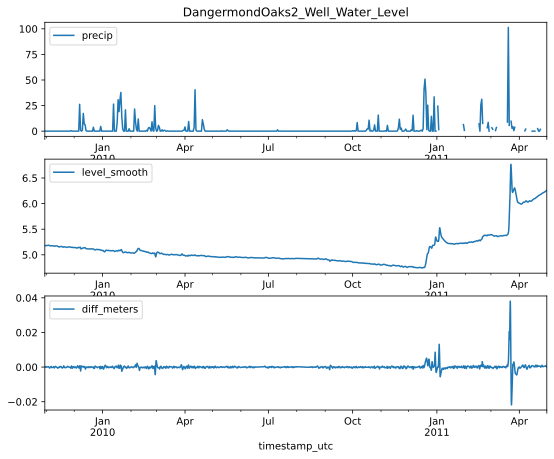

<Figure size 640x480 with 0 Axes>

DangermondOaks2_Well_Water_Level
cat-73
-------
DangermondOaks5_Well_Water_Level
Number of outliers dropped: 1
Number of outliers dropped: 17
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 13156 entries, 2009-10-29 21:00:00+00:00 to 2011-05-01 00:00:00+00:00
Freq: h
Data columns (total 5 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   DangermondOaks5_Well_Water_Level          13156 non-null  float64
 1   baro_m                                    13156 non-null  float64
 2   DangermondOaks5_Well_Water_Level_barocor  13156 non-null  float64
 3   level_smooth                              13156 non-null  float64
 4   diff_meters                               13155 non-null  float64
dtypes: float64(5)
memory usage: 616.7 KB
None


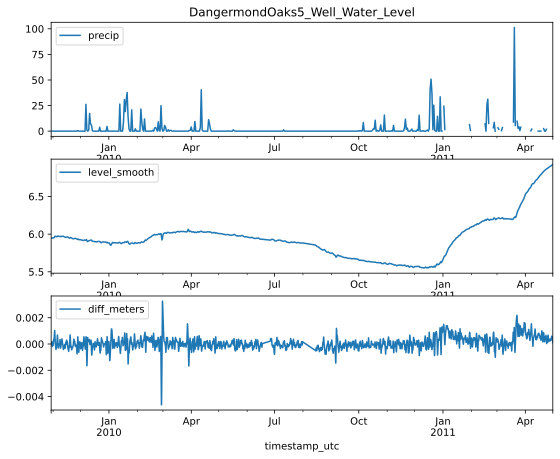

<Figure size 640x480 with 0 Axes>

DangermondOaks5_Well_Water_Level
cat-8
-------
DangermondOaks4_Well_Water_Level
Number of outliers dropped: 0
Number of outliers dropped: 137
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 13155 entries, 2009-10-29 22:00:00+00:00 to 2011-05-01 00:00:00+00:00
Freq: h
Data columns (total 5 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   DangermondOaks4_Well_Water_Level          13155 non-null  float64
 1   baro_m                                    13155 non-null  float64
 2   DangermondOaks4_Well_Water_Level_barocor  13155 non-null  float64
 3   level_smooth                              13155 non-null  float64
 4   diff_meters                               13154 non-null  float64
dtypes: float64(5)
memory usage: 616.6 KB
None


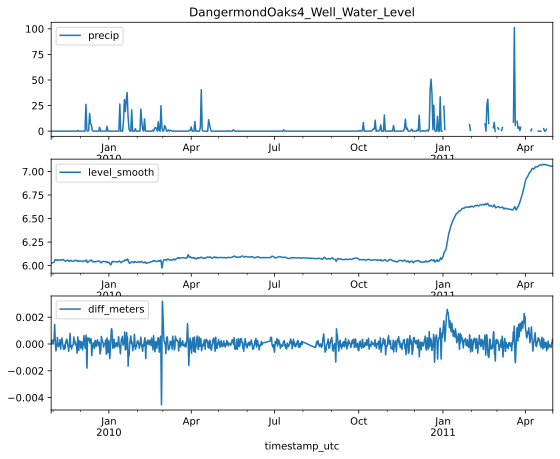

<Figure size 640x480 with 0 Axes>

DangermondOaks4_Well_Water_Level
cat-10
-------
DangermondOaks3_Well_Water_Level
Number of outliers dropped: 0
Number of outliers dropped: 15
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6073 entries, 2010-08-21 00:00:00+00:00 to 2011-05-01 00:00:00+00:00
Freq: h
Data columns (total 5 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   DangermondOaks3_Well_Water_Level          6073 non-null   float64
 1   baro_m                                    6073 non-null   float64
 2   DangermondOaks3_Well_Water_Level_barocor  6073 non-null   float64
 3   level_smooth                              6073 non-null   float64
 4   diff_meters                               6072 non-null   float64
dtypes: float64(5)
memory usage: 284.7 KB
None


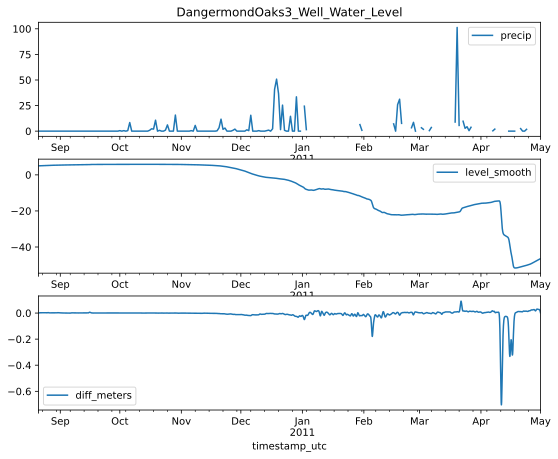

<Figure size 640x480 with 0 Axes>

DangermondOaks3_Well_Water_Level
cat-8
-------
DangermondGaucho2_Well_Water_Level
no data for DangermondGaucho2_Well_Water_Level
-------
DangermondNorthramajal_Well_Water_Level
no data for DangermondNorthramajal_Well_Water_Level
-------
DangermondJalachichi1_Well_Water_Level
no data for DangermondJalachichi1_Well_Water_Level
-------
DangermondTinta10_Well_Water_Level
no data for DangermondTinta10_Well_Water_Level
-------
DangermondVenadito1_Well_Water_Level
no data for DangermondVenadito1_Well_Water_Level
-------
DangermondVaqueros_Well_Water_Level
no data for DangermondVaqueros_Well_Water_Level
-------
DangermondTinta11B_Well_Water_Level
Number of outliers dropped: 579
Number of outliers dropped: 615
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 0 entries
Freq: h
Data columns (total 5 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   DangermondTinta11B_Well_Water_Lev

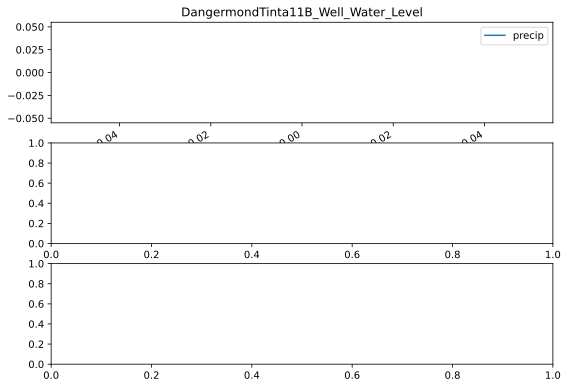

<Figure size 640x480 with 0 Axes>

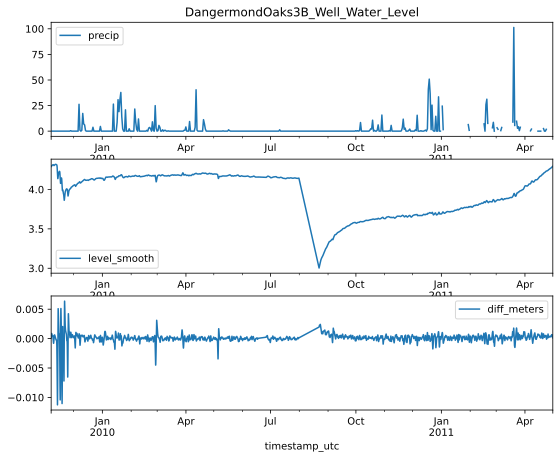

<Figure size 640x480 with 0 Axes>

DangermondOaks3B_Well_Water_Level
cat-8
-------
DangermondTinta4_Well_Water_Level
Number of outliers dropped: 17
Number of outliers dropped: 42
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 13177 entries, 2009-10-29 00:00:00+00:00 to 2011-05-01 00:00:00+00:00
Freq: h
Data columns (total 5 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   DangermondTinta4_Well_Water_Level          13177 non-null  float64
 1   baro_m                                     13177 non-null  float64
 2   DangermondTinta4_Well_Water_Level_barocor  13177 non-null  float64
 3   level_smooth                               13177 non-null  float64
 4   diff_meters                                13176 non-null  float64
dtypes: float64(5)
memory usage: 617.7 KB
None


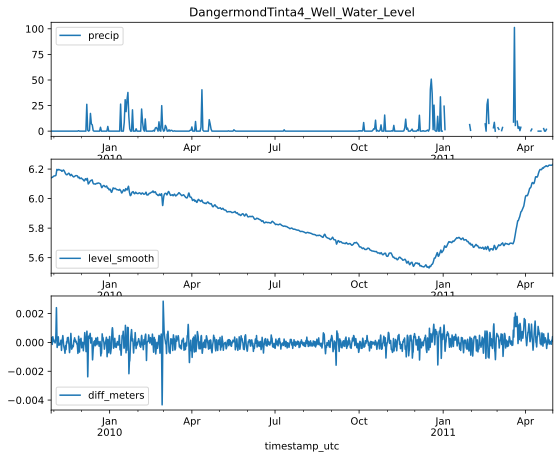

<Figure size 640x480 with 0 Axes>

DangermondTinta4_Well_Water_Level
cat-53
-------
DangermondEscondido5_Well_Water_Level
Number of outliers dropped: 1419
Number of outliers dropped: 1453
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 0 entries
Freq: h
Data columns (total 5 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   DangermondEscondido5_Well_Water_Level          0 non-null      float64
 1   baro_m                                         0 non-null      float64
 2   DangermondEscondido5_Well_Water_Level_barocor  0 non-null      float64
 3   level_smooth                                   0 non-null      float64
 4   diff_meters                                    0 non-null      float64
dtypes: float64(5)
memory usage: 0.0 bytes
None
qc or plotting error
/Users/dillonragar/github/TNC_dangermond/station_data/output/tnc_datastreams_v3/Dangermond_Escondido_5/DangermondEscondido5_Well_Water_Level.pa

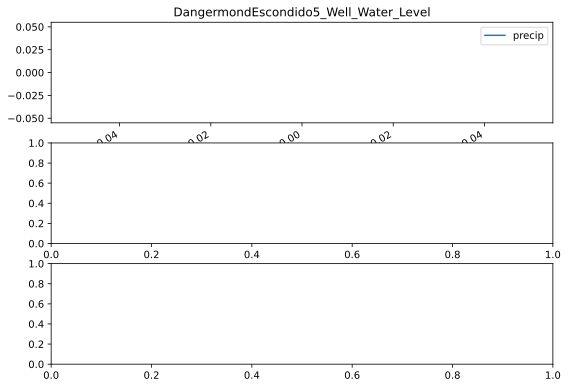

<Figure size 640x480 with 0 Axes>

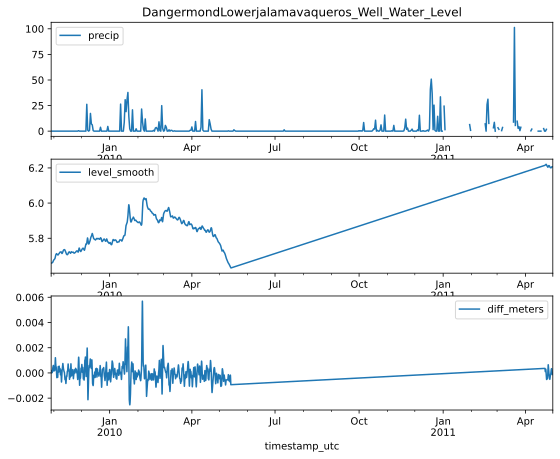

<Figure size 640x480 with 0 Axes>

DangermondLowerjalamavaqueros_Well_Water_Level
cat-58
-------
DangermondTinta3_Well_Water_Level
Number of outliers dropped: 1
Number of outliers dropped: 36
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 13202 entries, 2009-10-27 23:00:00+00:00 to 2011-05-01 00:00:00+00:00
Freq: h
Data columns (total 5 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   DangermondTinta3_Well_Water_Level          13202 non-null  float64
 1   baro_m                                     13202 non-null  float64
 2   DangermondTinta3_Well_Water_Level_barocor  13202 non-null  float64
 3   level_smooth                               13202 non-null  float64
 4   diff_meters                                13201 non-null  float64
dtypes: float64(5)
memory usage: 618.8 KB
None


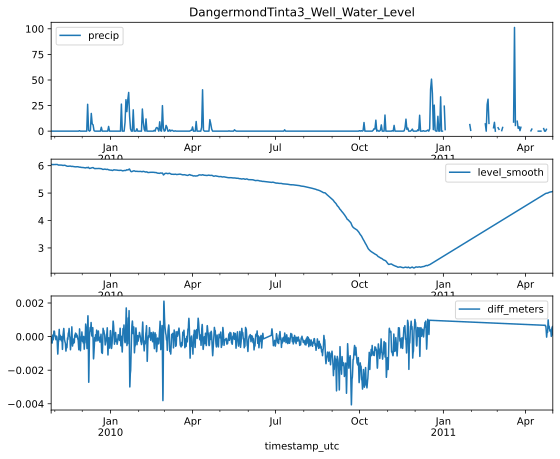

<Figure size 640x480 with 0 Axes>

DangermondTinta3_Well_Water_Level
cat-53
-------
DangermondEscondido2_Well_Water_Level
Number of outliers dropped: 5011
Number of outliers dropped: 5047
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 13012 entries, 2009-11-04 21:00:00+00:00 to 2011-05-01 00:00:00+00:00
Freq: h
Data columns (total 5 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   DangermondEscondido2_Well_Water_Level          13012 non-null  float64
 1   baro_m                                         13012 non-null  float64
 2   DangermondEscondido2_Well_Water_Level_barocor  13012 non-null  float64
 3   level_smooth                                   13012 non-null  float64
 4   diff_meters                                    13011 non-null  float64
dtypes: float64(5)
memory usage: 609.9 KB
None


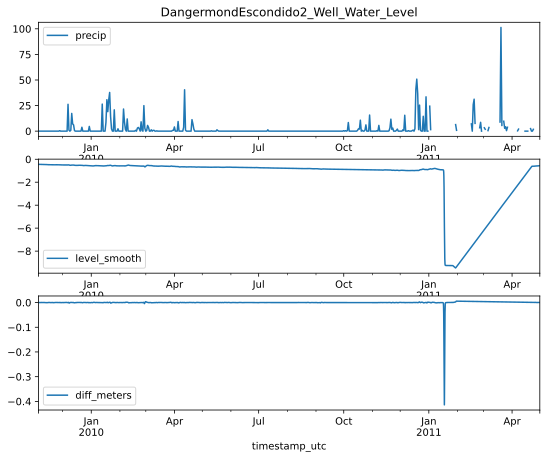

<Figure size 640x480 with 0 Axes>

DangermondEscondido2_Well_Water_Level
cat-31
-------
DangermondBuckhorn2_Well_Water_Level
no data for DangermondBuckhorn2_Well_Water_Level
-------
DangermondTinta2_Well_Water_Level
Number of outliers dropped: 0
Number of outliers dropped: 23
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 13200 entries, 2009-10-28 01:00:00+00:00 to 2011-05-01 00:00:00+00:00
Freq: h
Data columns (total 5 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   DangermondTinta2_Well_Water_Level          13200 non-null  float64
 1   baro_m                                     13200 non-null  float64
 2   DangermondTinta2_Well_Water_Level_barocor  13200 non-null  float64
 3   level_smooth                               13200 non-null  float64
 4   diff_meters                                13199 non-null  float64
dtypes: float64(5)
memory usage: 618.8 KB
None


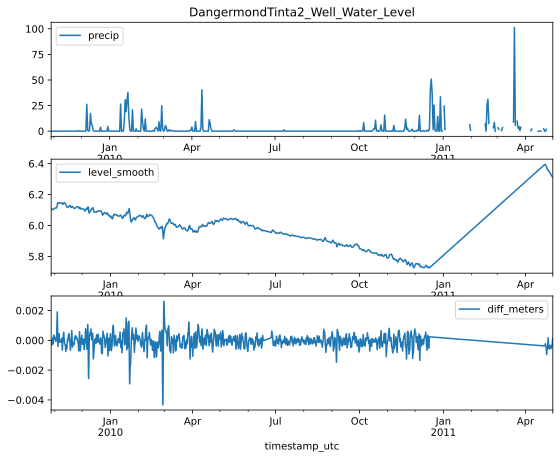

<Figure size 640x480 with 0 Axes>

DangermondTinta2_Well_Water_Level
cat-53
-------
DangermondEscondido3_Well_Water_Level
Number of outliers dropped: 10
Number of outliers dropped: 61
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 13180 entries, 2009-10-28 21:00:00+00:00 to 2011-05-01 00:00:00+00:00
Freq: h
Data columns (total 5 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   DangermondEscondido3_Well_Water_Level          13180 non-null  float64
 1   baro_m                                         13180 non-null  float64
 2   DangermondEscondido3_Well_Water_Level_barocor  13180 non-null  float64
 3   level_smooth                                   13180 non-null  float64
 4   diff_meters                                    13179 non-null  float64
dtypes: float64(5)
memory usage: 617.8 KB
None


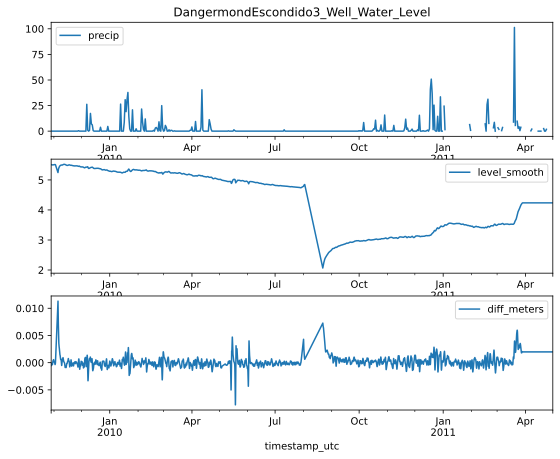

<Figure size 640x480 with 0 Axes>

DangermondEscondido3_Well_Water_Level
cat-30
-------
DangermondTinta5_Well_Water_Level
Number of outliers dropped: 0
Number of outliers dropped: 18
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 13178 entries, 2009-10-28 23:00:00+00:00 to 2011-05-01 00:00:00+00:00
Freq: h
Data columns (total 5 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   DangermondTinta5_Well_Water_Level          13178 non-null  float64
 1   baro_m                                     13178 non-null  float64
 2   DangermondTinta5_Well_Water_Level_barocor  13178 non-null  float64
 3   level_smooth                               13178 non-null  float64
 4   diff_meters                                13177 non-null  float64
dtypes: float64(5)
memory usage: 617.7 KB
None


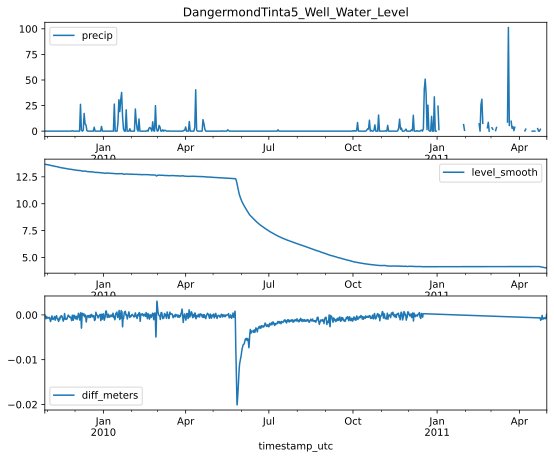

<Figure size 640x480 with 0 Axes>

DangermondTinta5_Well_Water_Level
cat-54
-------
DangermondEscondido4_Well_Water_Level
Number of outliers dropped: 0
Number of outliers dropped: 13
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 12961 entries, 2009-11-07 00:00:00+00:00 to 2011-05-01 00:00:00+00:00
Freq: h
Data columns (total 5 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   DangermondEscondido4_Well_Water_Level          12961 non-null  float64
 1   baro_m                                         12961 non-null  float64
 2   DangermondEscondido4_Well_Water_Level_barocor  12961 non-null  float64
 3   level_smooth                                   12961 non-null  float64
 4   diff_meters                                    12960 non-null  float64
dtypes: float64(5)
memory usage: 607.5 KB
None


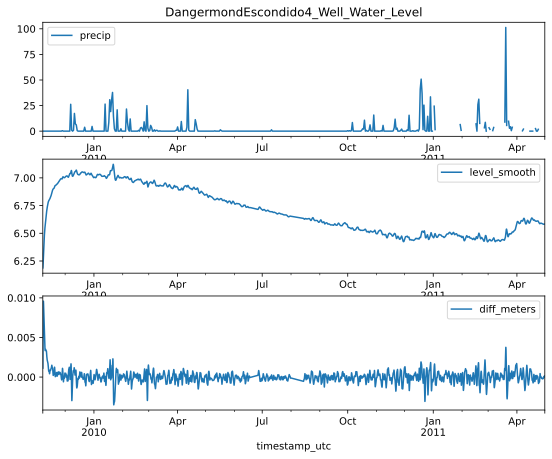

<Figure size 640x480 with 0 Axes>

DangermondEscondido4_Well_Water_Level
cat-30
-------
DangermondGaspar1_Well_Water_Level
no data for DangermondGaspar1_Well_Water_Level
-------
DangermondOaks1_Well_Water_Level
Number of outliers dropped: 3339
Number of outliers dropped: 3357
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 13154 entries, 2009-10-29 23:00:00+00:00 to 2011-05-01 00:00:00+00:00
Freq: h
Data columns (total 5 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   DangermondOaks1_Well_Water_Level          13154 non-null  float64
 1   baro_m                                    13154 non-null  float64
 2   DangermondOaks1_Well_Water_Level_barocor  13154 non-null  float64
 3   level_smooth                              13154 non-null  float64
 4   diff_meters                               13153 non-null  float64
dtypes: float64(5)
memory usage: 616.6 KB
None


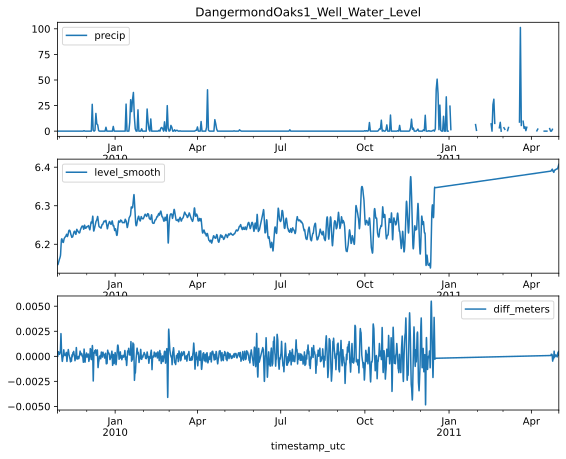

<Figure size 640x480 with 0 Axes>

DangermondOaks1_Well_Water_Level
cat-94
-------
DangermondCojocanyon_Well_Water_Level
no data for DangermondCojocanyon_Well_Water_Level
-------
DangermondQuailcanyon1_Well_Water_Level
Number of outliers dropped: 0
Number of outliers dropped: 10
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 13152 entries, 2009-10-30 01:00:00+00:00 to 2011-05-01 00:00:00+00:00
Freq: h
Data columns (total 5 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   DangermondQuailcanyon1_Well_Water_Level          13152 non-null  float64
 1   baro_m                                           13152 non-null  float64
 2   DangermondQuailcanyon1_Well_Water_Level_barocor  13152 non-null  float64
 3   level_smooth                                     13152 non-null  float64
 4   diff_meters                                      13151 non-null  float64
dtypes: float64(5)
memory usage: 616.5 KB
None

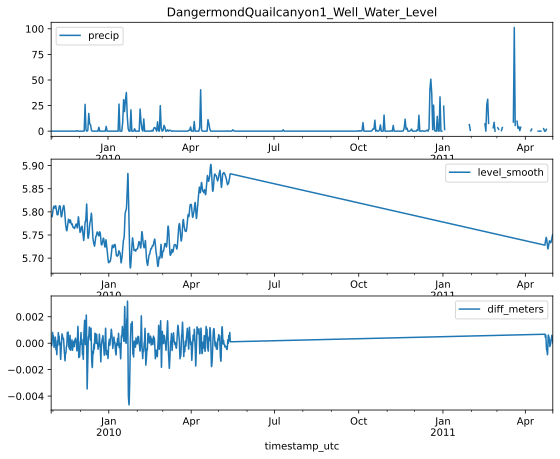

<Figure size 640x480 with 0 Axes>

DangermondQuailcanyon1_Well_Water_Level
cat-62
-------
DangermondEscondido3B_Well_Water_Level
Number of outliers dropped: 0
Number of outliers dropped: 19
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 13013 entries, 2009-11-04 20:00:00+00:00 to 2011-05-01 00:00:00+00:00
Freq: h
Data columns (total 5 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   DangermondEscondido3B_Well_Water_Level          13013 non-null  float64
 1   baro_m                                          13013 non-null  float64
 2   DangermondEscondido3B_Well_Water_Level_barocor  13013 non-null  float64
 3   level_smooth                                    13013 non-null  float64
 4   diff_meters                                     13012 non-null  float64
dtypes: float64(5)
memory usage: 610.0 KB
None


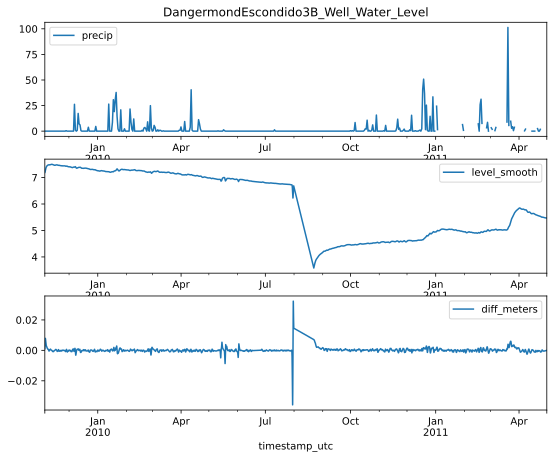

<Figure size 640x480 with 0 Axes>

DangermondEscondido3B_Well_Water_Level
cat-30
-------
DangermondSouthramajal_Well_Water_Level
no data for DangermondSouthramajal_Well_Water_Level
-------
DangermondLowerespada_Well_Water_Level
no data for DangermondLowerespada_Well_Water_Level
-------
DangermondTinta5B_Well_Water_Level
Number of outliers dropped: 0
Number of outliers dropped: 8
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 0 entries
Freq: h
Data columns (total 5 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   DangermondTinta5B_Well_Water_Level          0 non-null      float64
 1   baro_m                                      0 non-null      float64
 2   DangermondTinta5B_Well_Water_Level_barocor  0 non-null      float64
 3   level_smooth                                0 non-null      float64
 4   diff_meters                                 0 non-null      float64
dtypes: float64(5)
memory usage: 0.0 by

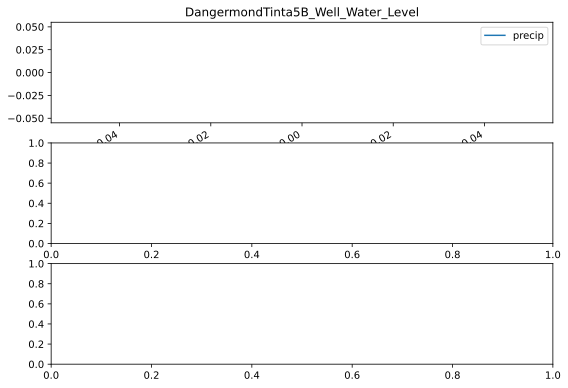

<Figure size 640x480 with 0 Axes>

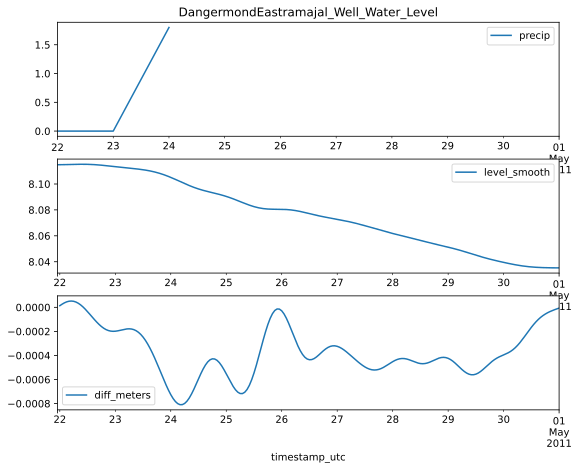

<Figure size 640x480 with 0 Axes>

DangermondEastramajal_Well_Water_Level
cat-69
-------
DangermondDamsitecanyon_Well_Water_Level
no data for DangermondDamsitecanyon_Well_Water_Level
-------
DangermondGaucho1_Well_Water_Level
no data for DangermondGaucho1_Well_Water_Level
-------
DangermondOldespada_Well_Water_Level
no data for DangermondOldespada_Well_Water_Level
-------
DangermondQuarry1_Well_Water_Level
no data for DangermondQuarry1_Well_Water_Level
-------
DangermondVenadito2_Well_Water_Level
Number of outliers dropped: 84
Number of outliers dropped: 95
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 13132 entries, 2009-10-30 21:00:00+00:00 to 2011-05-01 00:00:00+00:00
Freq: h
Data columns (total 5 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   DangermondVenadito2_Well_Water_Level          13132 non-null  float64
 1   baro_m                                        13132 non-null  float64
 2   Dan

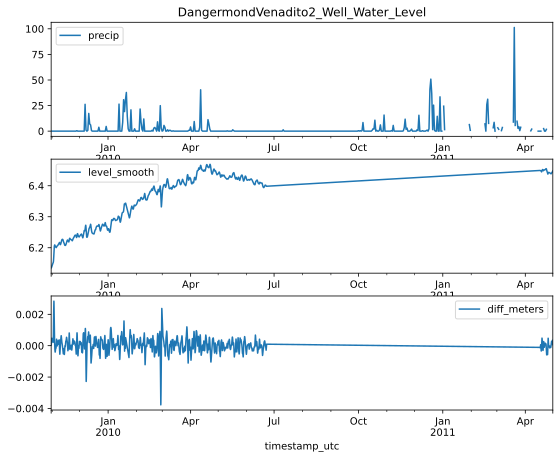

<Figure size 640x480 with 0 Axes>

DangermondVenadito2_Well_Water_Level
cat-88
-------
DangermondAlexanderramajal_Well_Water_Level
no data for DangermondAlexanderramajal_Well_Water_Level
-------
DangermondTestwell_Well_Water_Level
Number of outliers dropped: 0
Number of outliers dropped: 16
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 0 entries
Freq: h
Data columns (total 5 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   DangermondTestwell_Well_Water_Level          0 non-null      float64
 1   baro_m                                       0 non-null      float64
 2   DangermondTestwell_Well_Water_Level_barocor  0 non-null      float64
 3   level_smooth                                 0 non-null      float64
 4   diff_meters                                  0 non-null      float64
dtypes: float64(5)
memory usage: 0.0 bytes
None
qc or plotting error
/Users/dillonragar/github/TNC_dangermond/station_data

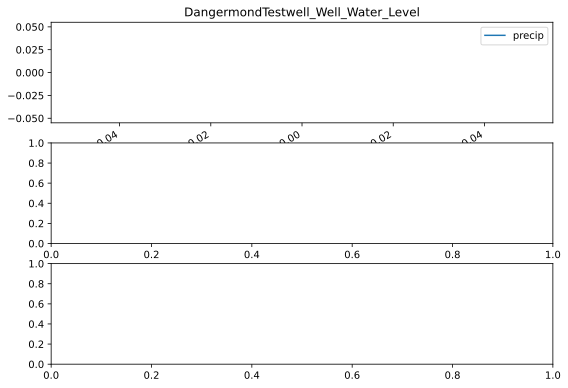

<Figure size 640x480 with 0 Axes>

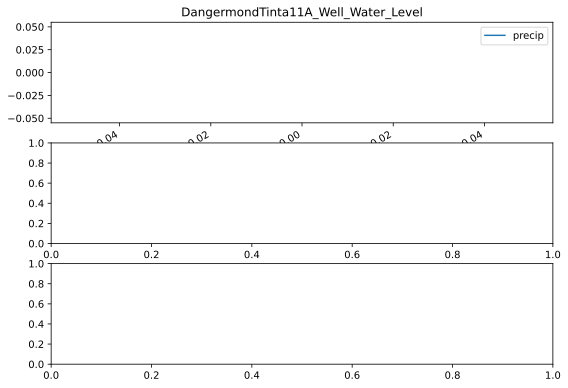

<Figure size 640x480 with 0 Axes>

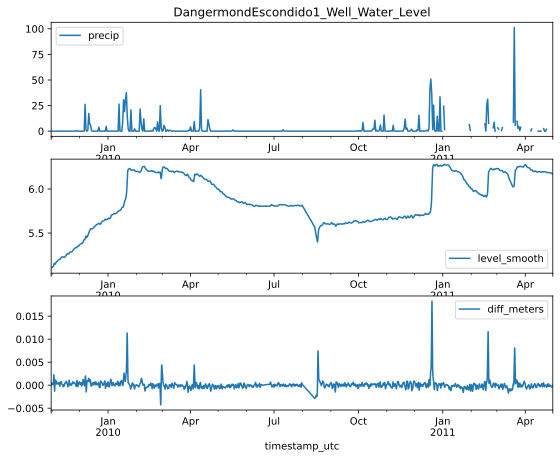

<Figure size 640x480 with 0 Axes>

DangermondEscondido1_Well_Water_Level
cat-31
-------
DangermondTinta7_Well_Water_Level
Number of outliers dropped: 3
Number of outliers dropped: 40
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 10349 entries, 2010-02-23 20:00:00+00:00 to 2011-05-01 00:00:00+00:00
Freq: h
Data columns (total 5 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   DangermondTinta7_Well_Water_Level          10349 non-null  float64
 1   baro_m                                     10349 non-null  float64
 2   DangermondTinta7_Well_Water_Level_barocor  10349 non-null  float64
 3   level_smooth                               10349 non-null  float64
 4   diff_meters                                10348 non-null  float64
dtypes: float64(5)
memory usage: 485.1 KB
None


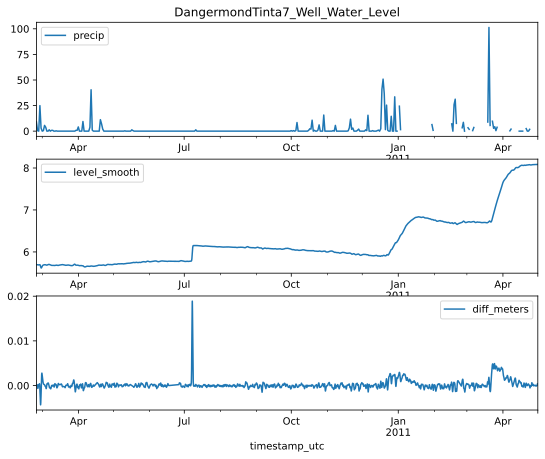

<Figure size 640x480 with 0 Axes>

DangermondTinta7_Well_Water_Level
cat-103
-------
DangermondUpperespada_Well_Water_Level
no data for DangermondUpperespada_Well_Water_Level
-------
DangermondTinta6_Well_Water_Level
Number of outliers dropped: 0
Number of outliers dropped: 9
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 13203 entries, 2009-10-27 22:00:00+00:00 to 2011-05-01 00:00:00+00:00
Freq: h
Data columns (total 5 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   DangermondTinta6_Well_Water_Level          13203 non-null  float64
 1   baro_m                                     13203 non-null  float64
 2   DangermondTinta6_Well_Water_Level_barocor  13203 non-null  float64
 3   level_smooth                               13203 non-null  float64
 4   diff_meters                                13202 non-null  float64
dtypes: float64(5)
memory usage: 618.9 KB
None


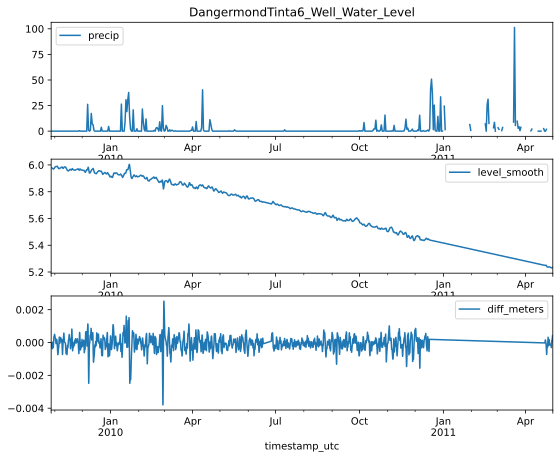

<Figure size 640x480 with 0 Axes>

DangermondTinta6_Well_Water_Level
cat-93
-------
DangermondTinta1_Well_Water_Level
Number of outliers dropped: 0
Number of outliers dropped: 5
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5742 entries, 2009-10-28 20:00:00+00:00 to 2010-06-25 01:00:00+00:00
Freq: h
Data columns (total 5 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   DangermondTinta1_Well_Water_Level          5742 non-null   float64
 1   baro_m                                     5742 non-null   float64
 2   DangermondTinta1_Well_Water_Level_barocor  5742 non-null   float64
 3   level_smooth                               5742 non-null   float64
 4   diff_meters                                5741 non-null   float64
dtypes: float64(5)
memory usage: 269.2 KB
None


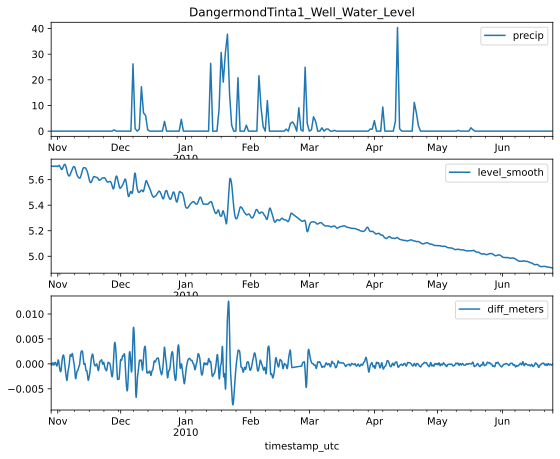

<Figure size 640x480 with 0 Axes>

DangermondTinta1_Well_Water_Level
cat-53
-------
DangermondWoodcanyon_Well_Water_Level
no data for DangermondWoodcanyon_Well_Water_Level
-------
DangermondTinta8_Well_Water_Level
no data for DangermondTinta8_Well_Water_Level


In [172]:
# n_steps = 2


# def diff(x):
#     return x.iloc[-1] - x.iloc[0]


qc_dfs = {}
qc_stations = []


for f in depth_files_recursive:
    print("-------")
    print(f.stem)
    column_name = f.stem
    df = pd.read_parquet(f)

    if len(df) > 1:
        try:

            # use utc time
            df.index = df["timestamp_utc"]
            # UNIT: feet to meters
            df[column_name] *= 0.3048

            # rm leading trailing nan
            df = groundwater_qc.leading_trailing_nan(df, column_name)
            # rm outliers w/ z-score
            df = groundwater_qc.detect_outliers_zscore(df, column_name)
            # apply rolling window
            df = groundwater_qc.drop_outliers_rolling(
                df, column_name, window=6, threshold=2
            )

            # add baro data
            df = groundwater_qc.baro_compensate(
                df=df, baro_series=df_baro["press_m"], col_name=column_name
            )

            # interpolate
            df = groundwater_qc.interpolate(df)

            # plotting
            # show precip
            min_bound = df.index.min()
            max_bound = df.index.max()

            fig, axes = plt.subplots(nrows=3, ncols=1, sharex=False)

            df_pcp.truncate(before=min_bound, after=max_bound)["PRCP"].plot(
                ax=axes[0], title=column_name, label="precip", legend=True
            )  # plot precip
            # qc_dfs[f][f].plot(figsize=(13, 13), ax=axes[1])  # plot QC'd data

            # print(f"{df.columns=}")
            # plot
            print(df.info())
            plt.figure()
            # df[[f"{column_name}_barocor", column_name]].plot(figsize=(13, 4))
            df[["level_smooth"]].plot(ax=axes[1], figsize=(9, 7))
            df[["diff_meters"]].plot(ax=axes[2], figsize=(9, 7))

            plt.show()
            print(column_name)

            # add catchment id to df
            metadata_path = f"{Path(f).parent}/Well_Water_Level_Metadata.json"

            with open(metadata_path, "r") as file:
                meta = json.load(file)

            station_id = meta["station_id"]
            cat_id = gdf[gdf["station_id_dendra"] == station_id]["divide_id"].values[0]
            print(cat_id)
            df["divide_id"] = cat_id

            qc_dfs[column_name] = df  # save df
            qc_stations.append(column_name)  # add all stations that pass QC to list

            #     # add to dict
        except:
            print("qc or plotting error")
            print(f)
            continue
    else:
        print(f"no data for {column_name}")

In [164]:
# wells with best data record in 2010-2011 period
best_wells = [
    "DangermondEscondido4_Well_Water_Level",
    "DangermondTinta4_Well_Water_Level",
    "DangermondOaks4_Well_Water_Level",
    "DangermondOaks5_Well_Water_Level",
    "DangermondOaks2_Well_Water_Level",
]

In [165]:
# use list of passing station to index dict and save
for i in best_wells:
    df = qc_dfs[i]
    # print(f"{df.columns}")
    print(df.info())

    min_bound = df.index.min().strftime("%Y%m%d")
    max_bound = df.index.max().strftime("%Y%m%d")

    df.to_parquet(
        f"./output/hourly_diff_qc/{i}_hourly_diff_m_{min_bound}_{max_bound}.parquet"
    )

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 12961 entries, 2009-11-07 00:00:00+00:00 to 2011-05-01 00:00:00+00:00
Freq: h
Data columns (total 6 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   DangermondEscondido4_Well_Water_Level          12961 non-null  float64
 1   baro_m                                         12961 non-null  float64
 2   DangermondEscondido4_Well_Water_Level_barocor  12961 non-null  float64
 3   level_smooth                                   12961 non-null  float64
 4   diff_meters                                    12960 non-null  float64
 5   divide_id                                      12961 non-null  object 
dtypes: float64(5), object(1)
memory usage: 708.8+ KB
None
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 13177 entries, 2009-10-29 00:00:00+00:00 to 2011-05-01 00:00:00+00:00
Freq: h
Data columns (total 6 columns):
 #   Co

In [166]:
qc_dfs["DangermondEscondido4_Well_Water_Level"]

,DangermondEscondido4_Well_Water_Level,baro_m,DangermondEscondido4_Well_Water_Level_barocor,level_smooth,diff_meters,divide_id
timestamp_utc,,,,,,
2009-11-07 00:00:00+00:00,16.468131,10.351178,6.116953,6.186625,NaN,cat-30
2009-11-07 01:00:00+00:00,16.478387,10.351178,6.127209,6.187755,0.001130,cat-30
2009-11-07 02:00:00+00:00,16.493635,10.355257,6.138378,6.189996,0.002240,cat-30
2009-11-07 03:00:00+00:00,16.508280,10.353217,6.155063,6.193307,0.003311,cat-30
2009-11-07 04:00:00+00:00,16.521692,10.354237,6.167455,6.197632,0.004325,cat-30
...,...,...,...,...,...,...
2011-04-30 20:00:00+00:00,16.956634,10.371572,6.585061,6.583028,0.000154,cat-30
2011-04-30 21:00:00+00:00,16.956314,10.370552,6.585761,6.583163,0.000135,cat-30
2011-04-30 22:00:00+00:00,16.957076,10.366474,6.590602,6.583272,0.000109,cat-30


In [167]:
template_index = qc_dfs["DangermondOaks2_Well_Water_Level"].loc["2009-11-08":].index
df_diff_hr = pd.DataFrame(index=template_index)
df_diff_hr.index.name = "value_date"


# process best wells to single file
for f in best_wells:
    print("---------------")
    print(f)

    # rm first diff nan and start on 10/30
    df = qc_dfs[f].loc["2009-11-08":]

    print(df)
    cat = df["divide_id"].iloc[0]
    df_diff_hr[f"value_{cat}"] = df["diff_meters"]

---------------
DangermondEscondido4_Well_Water_Level
                           DangermondEscondido4_Well_Water_Level     baro_m  \
timestamp_utc                                                                 
2009-11-08 00:00:00+00:00                              16.702720  10.326704   
2009-11-08 01:00:00+00:00                              16.709151  10.325685   
2009-11-08 02:00:00+00:00                              16.718234  10.320586   
2009-11-08 03:00:00+00:00                              16.726037  10.327724   
2009-11-08 04:00:00+00:00                              16.736690  10.330783   
...                                                          ...        ...   
2011-04-30 20:00:00+00:00                              16.956634  10.371572   
2011-04-30 21:00:00+00:00                              16.956314  10.370552   
2011-04-30 22:00:00+00:00                              16.957076  10.366474   
2011-04-30 23:00:00+00:00                              16.956054  10.366474  

In [168]:
df_diff_hr

,value_cat-30,value_cat-53,value_cat-10,value_cat-8,value_cat-73
value_date,,,,,
2009-11-08 00:00:00+00:00,0.008294,-0.000142,-0.000038,-0.000090,-0.000128
2009-11-08 01:00:00+00:00,0.008079,-0.000146,-0.000035,-0.000088,-0.000130
2009-11-08 02:00:00+00:00,0.007866,-0.000146,-0.000026,-0.000078,-0.000123
2009-11-08 03:00:00+00:00,0.007661,-0.000139,-0.000009,-0.000060,-0.000109
2009-11-08 04:00:00+00:00,0.007466,-0.000127,0.000015,-0.000033,-0.000087
...,...,...,...,...,...
2011-04-30 20:00:00+00:00,0.000154,0.000341,0.000297,0.000412,0.000491
2011-04-30 21:00:00+00:00,0.000135,0.000292,0.000253,0.000345,0.000416
2011-04-30 22:00:00+00:00,0.000109,0.000231,0.000199,0.000268,0.000326


In [169]:
df_diff_hr.to_parquet(
    "./output/hourly_diff_qc/hourly_level_diff_meters_smoothed_20091108_20110501.parquet"
)

In [162]:
# df_diff_hr.to_parquet("./output/hourly_diff_qc/hourly_level_diff_meters_raw_20091108_20110501.parquet")

In [173]:
pd.read_parquet(
    "./output/hourly_diff_qc/hourly_level_diff_meters_smoothed_20091108_20110501.parquet"
)

,value_cat-30,value_cat-53,value_cat-10,value_cat-8,value_cat-73
value_date,,,,,
2009-11-08 00:00:00+00:00,0.008294,-0.000142,-0.000038,-0.000090,-0.000128
2009-11-08 01:00:00+00:00,0.008079,-0.000146,-0.000035,-0.000088,-0.000130
2009-11-08 02:00:00+00:00,0.007866,-0.000146,-0.000026,-0.000078,-0.000123
2009-11-08 03:00:00+00:00,0.007661,-0.000139,-0.000009,-0.000060,-0.000109
2009-11-08 04:00:00+00:00,0.007466,-0.000127,0.000015,-0.000033,-0.000087
...,...,...,...,...,...
2011-04-30 20:00:00+00:00,0.000154,0.000341,0.000297,0.000412,0.000491
2011-04-30 21:00:00+00:00,0.000135,0.000292,0.000253,0.000345,0.000416
2011-04-30 22:00:00+00:00,0.000109,0.000231,0.000199,0.000268,0.000326


In [174]:
pd.read_parquet(
    "./output/hourly_diff_qc/hourly_level_diff_meters_raw_20091108_20110501.parquet"
)

,value_cat-30,value_cat-53,value_cat-10,value_cat-8,value_cat-73
value_date,,,,,
2009-11-08 00:00:00+00:00,0.005032,-0.004143,-0.006749,-0.008364,-0.007716
2009-11-08 01:00:00+00:00,0.007451,-0.000824,-0.000580,0.000250,-0.002668
2009-11-08 02:00:00+00:00,0.014182,0.001822,0.006287,0.007788,0.004992
2009-11-08 03:00:00+00:00,0.000665,-0.006513,-0.005705,-0.006254,-0.005561
2009-11-08 04:00:00+00:00,0.007594,-0.003303,-0.002853,-0.003364,-0.003204
...,...,...,...,...,...
2011-04-30 20:00:00+00:00,0.000639,0.000357,0.000364,0.000403,0.003047
2011-04-30 21:00:00+00:00,0.000700,0.000098,-0.001259,-0.000794,0.002925
2011-04-30 22:00:00+00:00,0.004841,0.003675,0.002723,0.003370,0.002982


In [27]:
# # load prcp data
# df_pcp = pd.read_parquet(
#     "/Users/dillonragar/github/TNC_dangermond/station_data/output/qc/GHCND:USC00045064_19770101_20240430.parquet"
# )

# for f in qc_stations:
#     print("---------------")
#     print(f)
#     df1 = qc_dfs[f]

#     # get id so it can be reassigned
#     stn_id_dendra = (
#         df1["stn_id_dendra"].iloc[0] if "stn_id_dendra" in df1.columns else None
#     )

#     df1[f] *= 0.3048  # UNIT: feet to meters

#     # df1[f].plot()
#     df2 = df1[[f]].resample("MS").mean()
#     df2 = df2.rolling(window=2).apply(diff)
#     df2 *= -1  # data is distance to water, so inverse sign shows groundwater input

#     # show precip
#     min_bound = df2.index.min()
#     max_bound = df2.index.max()

#     fig, axes = plt.subplots(nrows=3, ncols=1, sharex=True)

#     df_pcp.truncate(before=min_bound, after=max_bound)["PRCP"].plot(
#         ax=axes[0]
#     )  # plot precip
#     qc_dfs[f][f].plot(figsize=(13, 13), ax=axes[1])  # plot QC'd data

#     # show delta
#     df2.plot(ax=axes[2], marker=".", markersize=10)
#     plt.show()

#     file_name = f"{f.split("_")[0]}_monthly_gw_delta_meters_{min_bound.strftime("%Y%d%m")}_{max_bound.strftime("%Y%d%m")}.parquet"
#     print(file_name)

#     # reassign station id
#     df2["stn_id_dendra"] = stn_id_dendra
#     df2.to_parquet(f"./output/gw_monthly_delta/{file_name}")